In [6]:
import pandas as pd
import feature_engineering_helper as hf
import pickle


In [ ]:

### change this to 1 for quick test, 0 for full run
quick_test = 0
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=40
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    print("Full run mode")



Quick test mode


In [8]:
data_prefix = '../0_data/processed_data/'
figure_prefix = '../Figures/'
label = 'MP_label'
non_feature_cols = ['SMILES', 'MP', 'Type'] + [label]
model_lists = ['LGB']
data_types = ['L', 'H', 'All']


if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features_scaled.parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

df_all_feature

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,SMILES,Type
0,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.43783,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-1.155375,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,Train
1,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.43783,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-0.552575,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,Train
2,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.43783,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.482897,Cc1cc(Br)c(cc1Br)C,Train
3,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.43783,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.495026,OC(=O)c1ccc(c(c1)F)C,Train
4,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.43783,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.704817,OC(=O)C1CC(=O)c2c1cccc2,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.43783,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.989775,COc1cc2oc(cc(=O)c2c(c1OC)O)c1ccc(c(c1)O)OC,Train
496,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.43783,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-0.424414,CCC(=O)c1cc(O)ccc1O,Train
497,0.0,0.0,0.0,2.683282,1.605258,-0.476047,-0.43783,2.305994,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.815013,O=C(C12CC3CC(C2)CC(C1)C3)NCCOCC(=O)O,Train
498,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.43783,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.795002,O=COC1CCC2C1(C)CCC1C2CCC2C1(C)CCC(=O)C2,Train


In [13]:
def feature_engineering_workflow(model_type, df):

    data = df.copy()
    tolerance = 0.01

    # Extract all feature columns
    all_feature_cols = data.drop(columns=non_feature_cols).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")
    print()

    # Reduce features by variance threshold
    variance_threshold = 0.01
    print(f'Variance threshold feature selection: variance_threshold={variance_threshold}')
    df_X_variance = hf.reduce_features_by_variance(data[all_feature_cols], variance_threshold=variance_threshold)
    print()


    print(f'RFE feature selection: model={model_type}, tolerance={tolerance}, n_features_to_select={n_features_to_select}, step={step}')
    # Reduce features by RFE
    RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], model = model_type, tolerance = tolerance, n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
    print()

    # Plot RFE results
    hf.RFE_plot(RFE_results, tolerance , model_type,save_path = figure_prefix + f'RFE_plot_{model_type}.png')


    df_X_RFE = df_X_variance[RFE_results['best_features']]


    return df_X_variance, RFE_results, df_X_RFE

Running feature engineering workflow with LGB model on L data
Number of samples: 474, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 26
Remaining features: 358

RFE feature selection: model=LGB, tolerance=0.01, n_features_to_select=40, step=50


RFE Feature Selection:   0%|          | 0/7 iteration

RFE Feature Selection:  14%|█▍        | 1/7 iteration

Iteration 0/7 | Features: 308 | RMSE: 44.7093 ± 4.2409 | Removed: [MACCS_100, MACCS_68, MACCS_70, MACCS_71, MACCS_72, MACCS_73, MACCS_75, MACCS_76, MACCS_77, MACCS_78, MACCS_79, MACCS_8, MACCS_80, MACCS_81, MACCS_83, MACCS_84, MACCS_85, MACCS_86, MACCS_88, MACCS_89, MACCS_97, RDKit_HeavyAtomCount, RDKit_MaxEStateIndex, RDKit_NumAliphaticCarbocycles, RDKit_NumAliphaticHeterocycles, RDKit_NumAliphaticRings, RDKit_NumAmideBonds, RDKit_NumAromaticCarbocycles, RDKit_NumAromaticHeterocycles, RDKit_NumAromaticRings, RDKit_NumAtomStereoCenters, RDKit_NumBridgeheadAtoms, RDKit_NumHeterocycles, RDKit_NumSaturatedCarbocycles, RDKit_NumSaturatedHeterocycles, RDKit_NumSaturatedRings, RDKit_NumSpiroAtoms, RDKit_PEOE_VSA13, RDKit_PEOE_VSA5, RDKit_SMR_VSA2, RDKit_SlogP_VSA7, RDKit_fr_Al_COO, RDKit_fr_Al_OH, RDKit_fr_Al_OH_noTert, RDKit_fr_Ar_COO, RDKit_fr_Ar_N, RDKit_fr_Ar_NH, RDKit_fr_Ar_OH, RDKit_fr_COO, RDKit_fr_urea]


RFE Feature Selection: 100%|██████████| 7/7 iteration



Global best RMSE: 44.1322
Threshold (1.0% tolerance): 44.5735

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 108
  Selected RMSE: 44.1322
  Best features (Top 5): ['RDKit_qed', 'RDKit_PEOE_VSA7', 'RDKit_SMR_VSA10', 'RDKit_VSA_EState4', 'RDKit_TPSA']



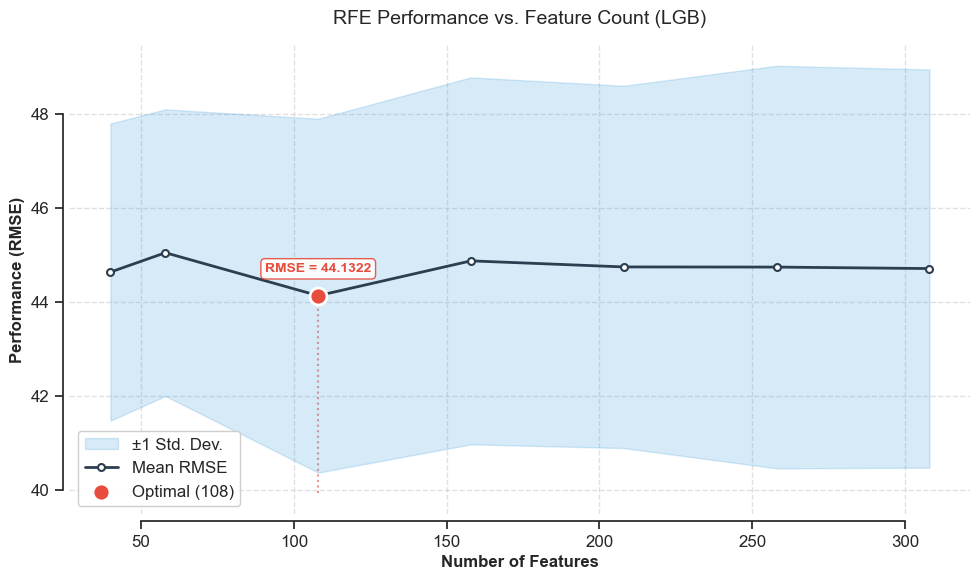

  Optimal Feature Set: 108 features
  Best RMSE: 44.1322

Running feature engineering workflow with LGB model on H data
Number of samples: 26, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 84
Remaining features: 300

RFE feature selection: model=LGB, tolerance=0.01, n_features_to_select=40, step=50


RFE Feature Selection:   0%|          | 0/6 iteration

Iteration 0/6 | Features: 250 | RMSE: 29.6218 ± 11.0390 | Removed: [MACCS_100, RDKit_EState_VSA11, RDKit_EState_VSA2, RDKit_EState_VSA3, RDKit_EState_VSA4, RDKit_EState_VSA5, RDKit_EState_VSA6, RDKit_EState_VSA7, RDKit_EState_VSA8, RDKit_EState_VSA9, RDKit_ExactMolWt, RDKit_FpDensityMorgan1, RDKit_FpDensityMorgan2, RDKit_NHOHCount, RDKit_NOCount, RDKit_NumAliphaticCarbocycles, RDKit_NumAliphaticHeterocycles, RDKit_NumAliphaticRings, RDKit_NumAmideBonds, RDKit_NumAromaticCarbocycles, RDKit_NumAromaticHeterocycles, RDKit_NumAromaticRings, RDKit_NumAtomStereoCenters, RDKit_NumBridgeheadAtoms, RDKit_NumHAcceptors, RDKit_NumHDonors, RDKit_NumHeteroatoms, RDKit_NumHeterocycles, RDKit_NumRotatableBonds, RDKit_NumSaturatedCarbocycles, RDKit_NumSaturatedHeterocycles, RDKit_NumSaturatedRings, RDKit_NumSpiroAtoms, RDKit_NumUnspecifiedAtomStereoCenters, RDKit_NumValenceElectrons, RDKit_PEOE_VSA1, RDKit_PEOE_VSA10, RDKit_PEOE_VSA11, RDKit_PEOE_VSA12, RDKit_PEOE_VSA13, RDKit_PEOE_VSA14, RDKit_PEOE_V

RFE Feature Selection: 100%|██████████| 6/6 iteration



Global best RMSE: 29.6218
Threshold (1.0% tolerance): 29.9180

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 40
  Selected RMSE: 29.6218
  Best features (Top 5): ['MACCS_106', 'MACCS_107', 'MACCS_128', 'MACCS_129', 'MACCS_130']



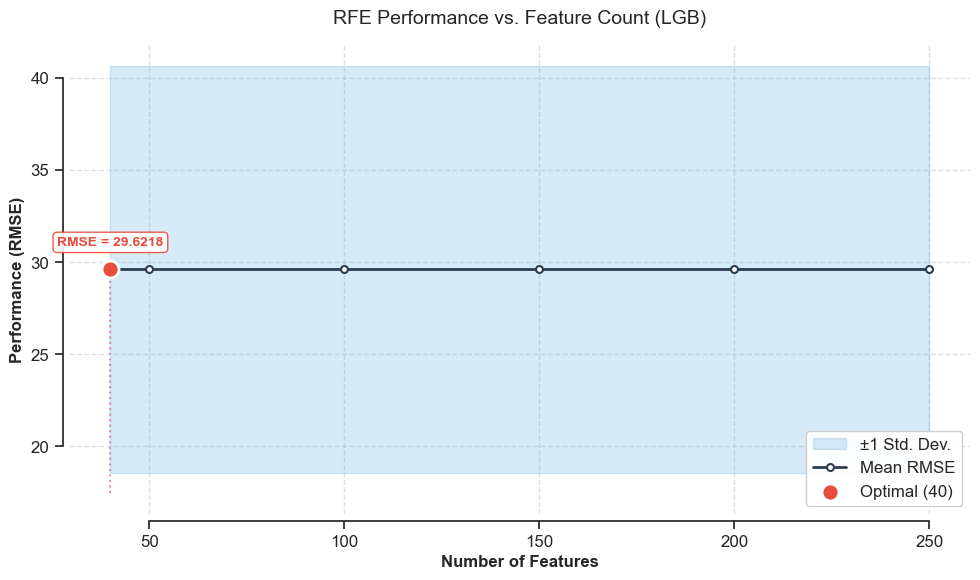

  Optimal Feature Set: 40 features
  Best RMSE: 29.6218

Running feature engineering workflow with LGB model on All data
Number of samples: 500, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 26
Remaining features: 358

RFE feature selection: model=LGB, tolerance=0.01, n_features_to_select=40, step=50


RFE Feature Selection:  14%|█▍        | 1/7 iteration

Iteration 0/7 | Features: 308 | RMSE: 47.4340 ± 7.4033 | Removed: [MACCS_100, MACCS_67, MACCS_68, MACCS_70, MACCS_71, MACCS_72, MACCS_74, MACCS_75, MACCS_76, MACCS_77, MACCS_78, MACCS_79, MACCS_8, MACCS_80, MACCS_81, MACCS_84, MACCS_86, MACCS_91, MACCS_93, MACCS_94, MACCS_97, RDKit_NumAmideBonds, RDKit_NumAromaticHeterocycles, RDKit_NumAromaticRings, RDKit_NumAtomStereoCenters, RDKit_NumBridgeheadAtoms, RDKit_NumSaturatedCarbocycles, RDKit_NumSaturatedHeterocycles, RDKit_NumSaturatedRings, RDKit_NumSpiroAtoms, RDKit_NumUnspecifiedAtomStereoCenters, RDKit_NumValenceElectrons, RDKit_PEOE_VSA4, RDKit_PEOE_VSA5, RDKit_SMR_VSA2, RDKit_SlogP_VSA11, RDKit_SlogP_VSA12, RDKit_SlogP_VSA7, RDKit_fr_Al_COO, RDKit_fr_Al_OH, RDKit_fr_Al_OH_noTert, RDKit_fr_ArN, RDKit_fr_Ar_COO, RDKit_fr_Ar_N, RDKit_fr_Ar_NH, RDKit_fr_Ar_OH, RDKit_fr_COO, RDKit_fr_COO2, RDKit_fr_C_O, RDKit_fr_C_O_noCOO]


RFE Feature Selection: 100%|██████████| 7/7 iteration



Global best RMSE: 46.8430
Threshold (1.0% tolerance): 47.3114

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 108
  Selected RMSE: 47.0183
  Best features (Top 5): ['RDKit_qed', 'RDKit_VSA_EState4', 'RDKit_PEOE_VSA7', 'RDKit_TPSA', 'RDKit_FpDensityMorgan3']



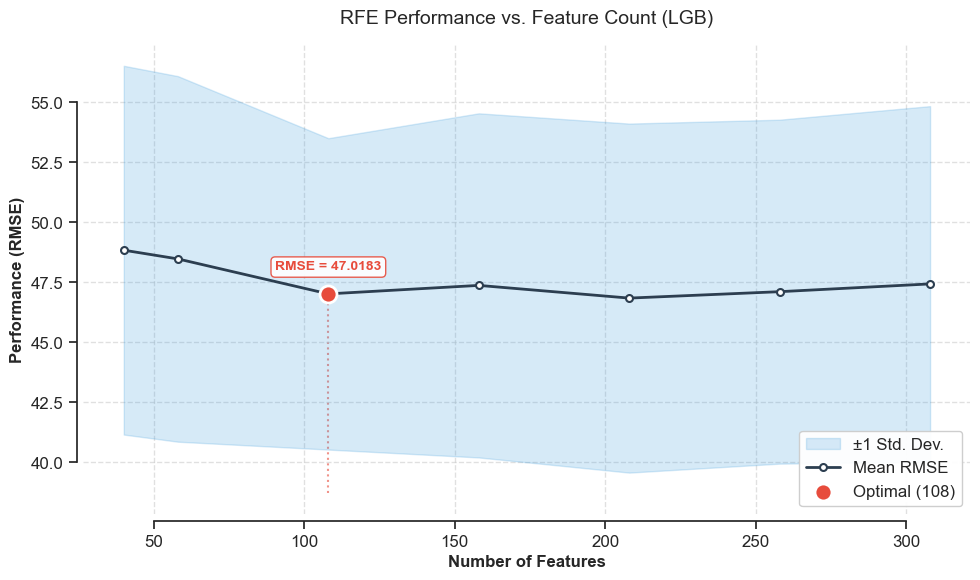

  Optimal Feature Set: 108 features
  Best RMSE: 47.0183



In [14]:
feature_engineering_dict = {}

for model_type in model_lists:

    for data_type in data_types:

        data_train = df_all_feature[df_all_feature['Type'] == 'Train']
        if data_type == 'L':
            data_with_features_train = data_train[data_train[label] == 'L']
        elif data_type == 'H':
            data_with_features_train = data_train[data_train[label] == 'H']
        else:
            data_with_features_train = data_train
        

        print(f"Running feature engineering workflow with {model_type} model on {data_type} data")
        print(f"Number of samples: {data_with_features_train.shape[0]}, Number of features: {data_with_features_train.shape[1]}")
        
        df_X_variance, RFE_results, df_X_RFE = feature_engineering_workflow(model_type, data_with_features_train)
        feature_engineering_dict[(model_type, data_type)] = RFE_results
        print()

# pickle save the feature_engineering_dict
with open('feature_engineering_dict.pkl', 'wb') as f:
    pickle.dump(feature_engineering_dict, f)

# Get the dataset

In [15]:
data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')
data_with_features_scaled = pd.read_parquet(data_prefix + 'data_with_all_features_scaled.parquet')

In [16]:
# load the feature_engineering_dict
with open('feature_engineering_dict.pkl', 'rb') as f:
    feature_engineering_dict = pickle.load(f)

In [19]:

for model_type in model_lists:
    for data_type in data_types:

        best_features = feature_engineering_dict[(model_type, data_type)]['best_features']
        print(f"Best features for {model_type} model - {data_type} data ({len(best_features)} features):")
        print(best_features)
        print()

        data_selected_features = data_with_features[non_feature_cols + best_features]
        data_selected_features_scaled = data_with_features_scaled[non_feature_cols + best_features]

        data_selected_features.to_parquet(data_prefix + f'data_with_selected_features_{model_type}_{data_type}.parquet')
        data_selected_features_scaled.to_parquet(data_prefix + f'data_with_selected_features_{model_type}_{data_type}_scaled.parquet')



Best features for LGB model - L data (108 features):
['RDKit_qed', 'RDKit_PEOE_VSA7', 'RDKit_SMR_VSA10', 'RDKit_VSA_EState4', 'RDKit_TPSA', 'RDKit_FpDensityMorgan2', 'RDKit_FpDensityMorgan1', 'RDKit_MinAbsEStateIndex', 'RDKit_PEOE_VSA6', 'RDKit_BalabanJ', 'RDKit_VSA_EState3', 'RDKit_MolLogP', 'RDKit_FpDensityMorgan3', 'RDKit_BertzCT', 'RDKit_EState_VSA3', 'RDKit_BCUT2D_MRHI', 'RDKit_EState_VSA5', 'RDKit_AvgIpc', 'RDKit_VSA_EState2', 'RDKit_BCUT2D_CHGHI', 'RDKit_VSA_EState5', 'RDKit_EState_VSA2', 'RDKit_SlogP_VSA2', 'RDKit_BCUT2D_LOGPLOW', 'RDKit_PEOE_VSA8', 'RDKit_VSA_EState6', 'RDKit_BCUT2D_LOGPHI', 'RDKit_Chi2v', 'RDKit_MinPartialCharge', 'RDKit_SPS', 'RDKit_FractionCSP3', 'RDKit_EState_VSA7', 'RDKit_HallKierAlpha', 'RDKit_EState_VSA9', 'RDKit_SMR_VSA5', 'RDKit_MaxAbsPartialCharge', 'RDKit_BCUT2D_CHGLO', 'RDKit_MinAbsPartialCharge', 'RDKit_EState_VSA8', 'RDKit_PEOE_VSA9', 'RDKit_BCUT2D_MWHI', 'RDKit_Chi2n', 'RDKit_EState_VSA4', 'RDKit_VSA_EState7', 'RDKit_VSA_EState8', 'RDKit_Chi4v',